# Importing quantum programs into QRE

The Quantum Resource Estimator (QRE) can accept applications written in several quantum programming languages and frameworks. This notebook demonstrates how to import programs from **Q#**, **Cirq**, **QIR** (Quantum Intermediate Representation), and **OpenQASM**, and then run resource estimation on each of them.

After running estimation on all four input formats, we go a step further and build a **custom application model**. This shows how to define your own `Application` subclass with configurable *trace parameters* (algorithmic hyperparameters that QRE varies automatically during estimation) and how to enrich results with custom columns derived from trace properties.

In [1]:
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import cirq
import qdk

from qiskit.circuit.library import RGQFTMultiplier
from qiskit.qasm3.exporter import Exporter

from qdk.qre import estimate, plot_estimates, Application
from qdk.qre.interop import trace_from_entry_expr
from qdk.qre.models import GateBased, RoundBasedFactory, SurfaceCode, TwoDimensionalYokedSurfaceCode
from qdk.qre.application import QSharpApplication, QIRApplication, CirqApplication, OpenQASMApplication
from qdk.qre.property_keys import custom_properties

## From Q#

Here we use the `%%qsharp` cell magic to define an inline Q# operation that performs ripple-carry addition on two registers of qubits. We then wrap the compiled entry point in a `QSharpApplication`, passing the register size as a runtime argument.

In [2]:
%%qsharp

import Std.Arithmetic.*;

// Ripple-carry addition on two n-qubit registers
operation Program(n : Int) : Unit {
    use a = Qubit[n];
    use b = Qubit[n];

    RippleCarryCGIncByLE(a, b);
}

In [3]:
# Wrap the compiled Q# entry point with a register size of 10 qubits
qsharp_app = QSharpApplication(qdk.code.Program, args=(10,))  # type: ignore

## From Cirq

`CirqApplication` accepts any `cirq.Circuit` directly. Here we build a 10-qubit Quantum Fourier Transform (QFT) circuit using Cirq's built-in `qft` helper and wrap it for resource estimation.

In [4]:
# Build a 10-qubit QFT circuit and wrap it for estimation
circuit = cirq.Circuit(cirq.qft(*cirq.LineQubit.range(10)))
cirq_app = CirqApplication(circuit)

## From QIR

Quantum Intermediate Representation (QIR) is an LLVM-based IR for quantum programs. `QIRApplication` accepts QIR as an LLVM IR string (or bitcode). Here we load a pre-compiled QIR file for a Hidden Shift algorithm.

In [5]:
# Load a pre-compiled QIR file for the Hidden Shift algorithm
qir_file = (
    Path.cwd().parent.parent
    / "source" / "pip" / "tests-integration" / "resources"
    / "adaptive_ri" / "output" / "HiddenShiftNISQ.ll"
)
qir_app = QIRApplication(qir_file.read_text(encoding="utf-8"))

## From OpenQASM (via Qiskit)

`OpenQASMApplication` accepts an OpenQASM 3 source string directly. Here we use Qiskit to generate an OpenQASM 3 program for a 4-qubit RGQFT multiplier and wrap it for resource estimation.

In [6]:
# Export a Qiskit circuit to OpenQASM 3
source = Exporter().dumps(RGQFTMultiplier(num_state_qubits=4))
qasm_app = OpenQASMApplication(source)

## Running resource estimation

With all four applications defined, we run resource estimation on each one to illustrate that any of the supported input formats can be used interchangeably. We use a `GateBased` architecture with 100 ns gate time and 500 ns measurement time, and query over `SurfaceCode` distances crossed with `RoundBasedFactory` protocols. The `max_error` parameter caps the total error probability at 1%.

Each call to `estimate` returns an `EstimationTable` of Pareto-optimal results: configurations where no other result achieves both fewer physical qubits *and* a shorter runtime within the error budget. Note that the four applications implement entirely different algorithms, so the results are not directly comparable; the purpose here is to show that QRE handles all input formats uniformly.

In [7]:
estimates = []

# Define the target architecture: gate-based with specified timing (ns)
arch = GateBased(gate_time=100, measurement_time=500)

# Explore surface code distances × round-based magic state factories
isa_query = SurfaceCode.q() * RoundBasedFactory.q()

for name, app in [("Q# adder", qsharp_app), ("cirq QFT", cirq_app), ("QIR HiddenShift", qir_app), ("OpenQASM multiplier", qasm_app)]:
    estimates.append(estimate(app, arch, isa_query, max_error=0.01, name=name))

We can plot the Pareto frontiers for each application. Since the four programs implement different algorithms, the plots are not meant for cross-algorithm comparison; they simply confirm that each input format produces valid estimation results.

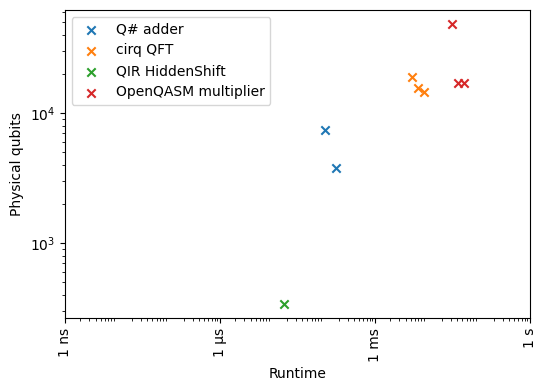

In [8]:
plot_estimates(estimates, figsize=(6, 4))

## Custom application model

The built-in application wrappers (`QSharpApplication`, `CirqApplication`, etc.) are convenient for importing existing circuits, but sometimes you need finer control. By subclassing `Application`, you can define a *custom application model* that separates two kinds of parameters:

- **Instance parameters** define *which* problem you are solving. They are fixed for a given estimation run. For example, the bit-size of an adder or the key length of an encryption scheme.
- **Trace parameters** are algorithmic hyperparameters that control *how* the problem is solved. QRE varies these automatically and explores all combinations during estimation. For example, the choice of adder circuit, the compute-to-memory ratio, or the eviction strategy.

Below we build a configurable adder application that lets QRE explore different adder implementations, compute fractions, and memory-management strategies for a given bit-size, and then compare the Pareto-optimal results.

In [9]:
%%qsharp
import Std.Arithmetic.*;
import Std.Convert.*;
import Std.Math.*;
import Std.ResourceEstimation.*;

// An adder operation that we will estimate together with instance and trace parameters
operation Adder(n : Int, adder: (Qubit[], Qubit[]) => Unit, computeFraction: Double, strategy: Int) : Unit {
    use a = Qubit[n];
    use b = Qubit[n];

    if computeFraction > 0.0 {
        // Enables an automatic memory/compute architecture with a fixed number of compute qubits
        // (computed as a fraction of the total number of qubits).  The strategy controls how
        // compute qubits are deallocated if free compute qubits are needed (either least recently
        // used or least frequently used).
        EnableMemoryComputeArchitecture(Ceiling(computeFraction * IntAsDouble(n)), strategy);
    }

    // Run the adder
    adder(a, b);

    // Reset all qubits (if code is used in simulation)
    ResetAll(a + b);
}

// Re-export adders and strategies to use in Python, together with strings to use in displaying the results
function CGAdder(): ((Qubit[], Qubit[]) => Unit, String) { (RippleCarryCGIncByLE, "CG") }
function TTKAdder(): ((Qubit[], Qubit[]) => Unit, String) { (RippleCarryTTKIncByLE, "TTK") }
function LRU(): (Int, String) { (LeastRecentlyUsed(), "LRU") }
function LFU(): (Int, String) { (LeastFrequentlyUsed(), "LFU") }

Trace parameters are defined as a `dataclass` with `kw_only=True`. Only keyword-only fields are treated as enumerable parameters by QRE; regular fields are considered fixed. Each keyword field must specify a `domain` in its `metadata` dict; this tells QRE which values to explore during estimation.

In the `AdderParameters` class below:

- **`adder`** selects the adder implementation: the Craig Gidney (CG) ripple-carry adder or the Takahashi–Tani–Kunihiro (TTK) ripple-carry adder.
- **`compute_fraction`** controls the ratio of qubits allocated to active computation versus memory, passed to `EnableMemoryComputeArchitecture` in the Q# operation.
- **`strategy`** chooses the eviction policy when compute capacity is exceeded: Least Recently Used (LRU) or Least Frequently Used (LFU).

Each field carries a default value (used when calling the application directly) and a domain (used when QRE enumerates all parameter combinations).

In [10]:
@dataclass(kw_only=True)
class AdderParameters:
    adder: tuple[Any, str] = field(default = qdk.code.CGAdder(), metadata={"domain": [qdk.code.CGAdder(), qdk.code.TTKAdder()]})
    compute_fraction: float = field(default=1.0, metadata={"domain": [0.5, 1.0, 1.5, 2.0]})
    strategy: tuple[int, str] = field(default=qdk.code.LRU(), metadata={"domain": [qdk.code.LRU(), qdk.code.LFU()]})

The `Adder` class subclasses `Application[AdderParameters]`, binding the trace-parameter type. Its single instance parameter, `bitsize`, is a regular (non-keyword) dataclass field that defines which problem instance to estimate.

Key details:

- **`get_trace(parameters)`** is the core method that QRE calls once for every combination of trace parameters. It invokes the Q# `Adder` operation with the current `bitsize` and the selected `adder`, `compute_fraction`, and `strategy` values, producing a resource-estimation trace.
- **`set_property`** attaches custom metadata (the adder name, compute fraction, and strategy name) to each trace. These properties are carried through estimation and can later be surfaced as custom columns in the results table.

In [11]:

# Property keys are integers; we can use the custom_properties function to
# define custom properties that do not conflict with existing properties.
ADDER, COMPUTE_FRACTION, STRATEGY = custom_properties(3)

@dataclass
class Adder(Application[AdderParameters]):
    bitsize: int

    def __post_init__(self):
        # Disable parallel trace generation since passing the Q# adder operations is not thread-safe.
        self.disable_parallel_traces()

    def get_trace(self, parameters: AdderParameters):
        # obtain the adder function and its name
        adder_fn, adder_name = parameters.adder
        # obtain the memory/compute strategy and its name
        strategy, strategy_name = parameters.strategy
        # generate a trace from the Q# entry point with the specified parameters
        trace = trace_from_entry_expr(qdk.code.Adder, self.bitsize, adder_fn, parameters.compute_fraction, strategy)

        # Set trace properties for later analysis and display
        trace.set_property(ADDER, adder_name)
        trace.set_property(COMPUTE_FRACTION, parameters.compute_fraction)
        trace.set_property(STRATEGY, strategy_name)

        return trace

Because the Q# operation enables a memory/compute architecture, the estimation must account for *memory qubits* in addition to compute and factory qubits. We extend the ISA query with `TwoDimensionalYokedSurfaceCode`, which models yoked surface codes for memory qubits on top of the lattice-surgery layer provided by `SurfaceCode`.

We also enrich the results table with additional columns:

- **`add_factory_summary_column()`** adds a human-readable summary of the magic-state factories used (e.g., `2×T, 1×CCZ`).
- **`add_qubit_partition_column()`** breaks the total physical qubit count into compute, factory, and memory partitions.
- Three **custom property columns** (`Adder`, `Compute fraction`, `Strategy`) surface the trace properties we attached earlier, so each row shows which algorithmic configuration produced that result.

In [12]:
isa_query = SurfaceCode.q() * RoundBasedFactory.q() * TwoDimensionalYokedSurfaceCode.q(source=SurfaceCode.q())

results = estimate(Adder(64), arch, isa_query, max_error=0.01, name="Configurable adder")
results.add_factory_summary_column()
results.add_qubit_partition_column()
results.add_property_column(ADDER, "adder")
results.add_property_column(COMPUTE_FRACTION, "compute_fraction")
results.add_property_column(STRATEGY, "strategy")
results.as_frame()

,name,qubits,runtime,error,factories,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,adder,compute_fraction,strategy
0,Configurable adder,14048,0 days 00:00:00.007940,0.009500,5×T,7448,4900,1700,TTK,1.0,LRU
1,Configurable adder,15028,0 days 00:00:00.006545,0.007920,6×T,7448,5880,1700,TTK,1.0,LFU
2,Configurable adder,15233,0 days 00:00:00.006205,0.008384,2×T,3969,680,10584,CG,0.5,LRU
3,Configurable adder,17729,0 days 00:00:00.006180,0.008911,6×T,10829,5880,1020,TTK,1.5,LRU
4,Configurable adder,18709,0 days 00:00:00.005010,0.007249,7×T,10829,6860,1020,TTK,1.5,LFU
5,Configurable adder,19781,0 days 00:00:00.004375,0.008869,4×T,14161,3920,1700,CG,2.0,LFU
6,Configurable adder,20761,0 days 00:00:00.003805,0.007727,5×T,14161,4900,1700,CG,2.0,LRU
7,Configurable adder,31801,0 days 00:00:00.001890,0.003385,18×T,14161,17640,0,TTK,2.0,LRU


The table above shows the Pareto-optimal configurations for a 64-bit adder. Each row represents a point on the Pareto frontier where no other configuration achieves both fewer physical qubits *and* a shorter runtime within the 1% error budget. The custom columns make it easy to see which adder implementation, compute fraction, and eviction strategy each result uses.

We can also visualize the Pareto frontier as a scatter plot of physical qubits versus runtime:

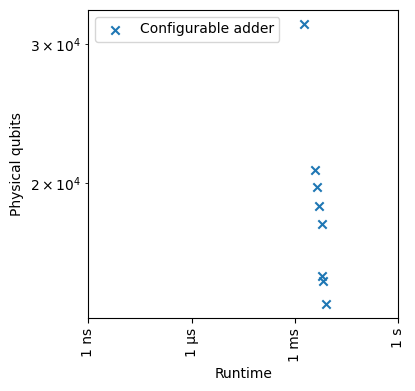

In [13]:
results.plot(figsize=(4, 4))

## Conclusion

This notebook demonstrated two ways to use the Quantum Resource Estimator:

1. **Importing existing programs.** QRE accepts quantum programs from Q#, Cirq, QIR, and OpenQASM through dedicated application wrappers, making it straightforward to estimate resources for circuits written in any of these frameworks.
2. **Building a custom application model.** By subclassing `Application` and defining trace parameters as a dataclass, you can let QRE automatically explore algorithmic hyperparameters (adder choice, compute fraction, eviction strategy) and compare Pareto-optimal results across all combinations.

For more details on inspecting and visualizing estimation results, see the [Analysing Resource Estimation Results](2_analysing_results.ipynb) notebook.